In [8]:
#First mount Drive for the dataset if it is not mounted or session is restarted.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Clone or pull the latest code
import os
REPO = "LaneDetection"
if not os.path.exists(f"/content/{REPO}"):
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/{REPO}
else:
    !cd /content/{REPO} && git pull

%cd /content/{REPO}

remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 9 (delta 5), reused 9 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 4.26 KiB | 1.06 MiB/s, done.
From https://github.com/abdullahtapanci/LaneDetection
   d696751..2391a32  main       -> origin/main
Updating d696751..2391a32
Fast-forward
 src/config.py          |   4 +-
 src/data/transforms.py |   4 +
 src/utils.py           |  40 ++++++
 train.ipynb            | 297 +++++++++++++++++++--------------------------
 trial.ipynb            | 321 +++++++++++++++++++++++++++++++++++++++++++++++++
 5 files changed, 493 insertions(+), 173 deletions(-)
 create mode 100644 trial.ipynb
/content/LaneDetection


Dataset length: 2900
Number of batches: 363



imgs        -> shape=(8, 3, 256, 512),        dtype=torch.float64,        min=-2.118, max=2.640
bin_masks   -> shape=(8, 1, 256, 512),   dtype=torch.float32,   unique=[0.0, 1.0]
inst_masks  -> shape=(8, 1, 256, 512),  dtype=torch.uint8,  unique=[0, 50, 100, 150, 200, 250]


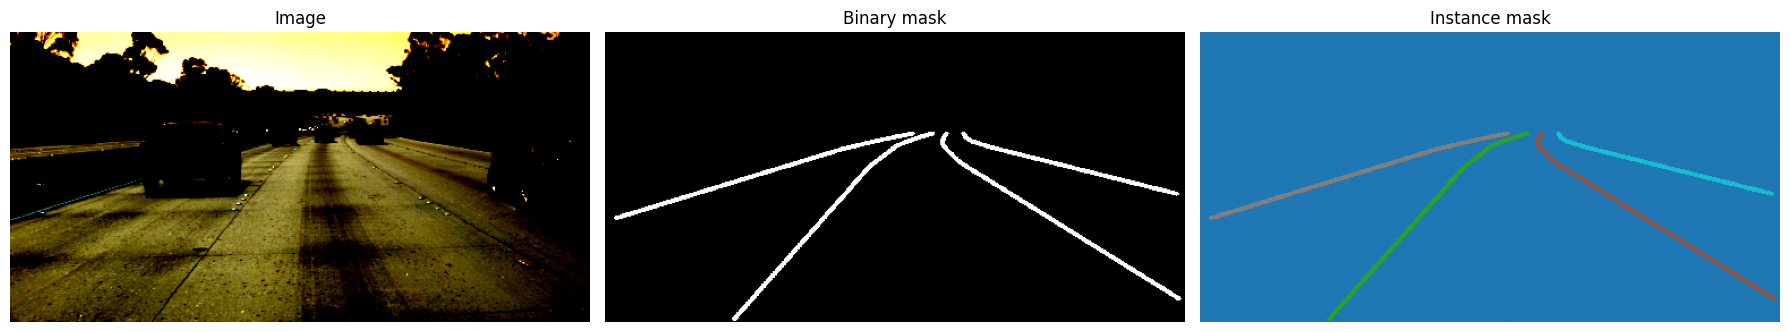

In [ ]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image

# 1. Build dataset + loader
manifest = f"{cfg.ROOT_DIR}/train.txt"
dataset = LaneDataset(manifest_path=manifest,
                      root_dir=cfg.ROOT_DIR,
                      transform=transform_image)

loader = DataLoader(dataset,
                    batch_size=cfg.BATCH_SIZE,
                    shuffle=True,
                    num_workers=2)

print(f"Dataset length: {len(dataset)}")
print(f"Number of batches: {len(loader)}")

# 2. Pull one batch and inspect shapes / dtypes / value ranges
imgs, bin_masks, inst_masks = next(iter(loader))

print(f"\nimgs        -> shape={tuple(imgs.shape)},        dtype={imgs.dtype},        min={imgs.min():.3f}, max={imgs.max():.3f}")
print(f"bin_masks   -> shape={tuple(bin_masks.shape)},   dtype={bin_masks.dtype},   unique={torch.unique(bin_masks).tolist()}")
print(f"inst_masks  -> shape={tuple(inst_masks.shape)},  dtype={inst_masks.dtype},  unique={torch.unique(inst_masks).tolist()}")

# Expected for batch_size=8, 256x512:
#   imgs       (8, 3, 256, 512), float32, [0, 1]
#   bin_masks  (8, 1, 256, 512), float32, [0., 1.]
#   inst_masks (8, 1, 256, 512), float32 or uint8, e.g. [0, 1, 2, 3, 4]

# 3. Visualize one sample from the batch
i = 0  # change to view different samples in the batch

# image: (C, H, W) -> (H, W, C); cv2 loaded BGR so swap to RGB for display
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img_np = imgs[i].permute(1, 2, 0).numpy()       # (H, W, C), already RGB
img_np = (img_np * std + mean).clip(0, 1)        # denormalize for display

bin_np  = bin_masks[i].squeeze(0).numpy()
inst_np = inst_masks[i].squeeze(0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_np);                 axes[0].set_title("Image");        axes[0].axis("off")
axes[1].imshow(bin_np, cmap="gray");    axes[1].set_title("Binary mask");  axes[1].axis("off")
axes[2].imshow(inst_np, cmap="tab10");  axes[2].set_title("Instance mask");axes[2].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import torch
from src.models.encoder import ENetEncoder

enc = ENetEncoder()
x = torch.randn(2, 3, 256, 512)
feats, idx1, idx2, s1, s2, inp = enc(x)

print("features:", feats.shape)        # (2, 128, 32, 64)
print("idx1:    ", idx1.shape)          # (2, 64, 64, 128)
print("idx2:    ", idx2.shape)          # (2, 128, 32, 64)
print("s1:", s1, "  s2:", s2, "  inp:", inp)
print("params:  ", sum(p.numel() for p in enc.parameters()))   # ~310-320k

In [ ]:
import torch
from src.models.encoder import ENetEncoder
from src.models.lanenet import LaneNetDecoder

enc = ENetEncoder()
dec = LaneNetDecoder(out_channels=2)   # binary head

x = torch.randn(2, 3, 256, 512)
feats, idx1, idx2, s1, s2, inp = enc(x)
out = dec(feats, idx1, idx2, s1, s2, inp)

print(out.shape)   # expect (2, 2, 256, 512)
print(sum(p.numel() for p in dec.parameters()))  # ~26-30k

In [ ]:
import torch
from src.models.lanenet import LaneNet

m = LaneNet(embedding_dim=4)
binary, embedding = m(torch.randn(2, 3, 256, 512))

print("binary:   ", binary.shape)     # (2, 2, 256, 512)
print("embedding:", embedding.shape)  # (2, 4, 256, 512)
print("params:   ", sum(p.numel() for p in m.parameters()))  # ~370k

In [4]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image

dataset = LaneDataset(
    manifest_path=f"{cfg.ROOT_DIR}/train.txt",
    root_dir=cfg.ROOT_DIR,
    transform=transform_image,
)
loader = DataLoader(dataset, batch_size=8, num_workers=2, shuffle=False)

total_pixels = 0
lane_pixels = 0

for _, bin_masks, _ in loader:
    # bin_masks: (B, 1, H, W) with values {0., 1.}
    total_pixels += bin_masks.numel()
    lane_pixels  += bin_masks.sum().item()

p_lane = lane_pixels / total_pixels
p_bg   = 1.0 - p_lane

# Paper's formula
c = 1.02
w_bg   = 1.0 / np.log(c + p_bg)
w_lane = 1.0 / np.log(c + p_lane)

print(f"p_background = {p_bg:.6f}   weight = {w_bg:.4f}")
print(f"p_lane       = {p_lane:.6f} weight = {w_lane:.4f}")

p_background = 0.972426   weight = 1.4506
p_lane       = 0.027574 weight = 21.5162


In [3]:
import torch

# Create two 1D tensors (Vectors)
t1 = torch.tensor([1, 2, 3])
t2 = torch.tensor([4, 5, 6])

# Stack them at dim 0 (creates a new dimension at the start)
stacked = torch.stack([t1, t2], dim=0)

print(stacked)

tensor([[1, 2, 3],
        [4, 5, 6]])


In [6]:
import torch
from src.models.lanenet import LaneNet
from src.loss import compute_loss

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LaneNet(embedding_dim=4).to(device)
B, H, W = 2, 256, 512
img = torch.randn(B, 3, H, W, device=device)

# Fake masks with 3 lane instances each
binary_mask = torch.zeros(B, 1, H, W, device=device)
inst_mask   = torch.zeros(B, 1, H, W, dtype=torch.long, device=device)
for k, lane_y in enumerate([60, 120, 180], start=1):
    binary_mask[:, :, lane_y:lane_y+5, :] = 1.0
    inst_mask[:,   :, lane_y:lane_y+5, :] = k

class_weights = torch.tensor([1.4506, 21.5162], device=device)

binary_logits, embedding = model(img)
total, comps = compute_loss(binary_logits, embedding,
                            binary_mask, inst_mask,
                            class_weights=class_weights)
total.backward()

print(comps)
print("encoder grad norm:",
      sum(p.grad.norm().item() for p in model.encoder.parameters() if p.grad is not None))

{'total': 36.421016693115234, 'binary': 0.8060316443443298, 'disc': 35.614986419677734, 'variance': 0.4657112956047058, 'distance': 35.14874267578125, 'reg': 0.5319617986679077}
encoder grad norm: 494.9077393787011
